# Read data from AIDev dataset

In [1]:
import pandas as pd

# Read the repos with more than 100 GitHub stars 
# Commit diffs (Additions, deletions, patches) 
original_df_commit_details = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_commit_details.parquet")
original_df_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
original_df_repos = pd.read_parquet("hf://datasets/hao-li/AIDev/repository.parquet")
original_df_issues = pd.read_parquet("hf://datasets/hao-li/AIDev/issue.parquet")
original_df_related_issues = pd.read_parquet("hf://datasets/hao-li/AIDev/related_issue.parquet")

c:\Users\User\Desktop\Modular-SWE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_commit_details = original_df_commit_details
df_prs = original_df_prs 
df_repos = original_df_repos
df_issues = original_df_issues 
df_related_issues = original_df_related_issues 

print(df_commit_details.columns)
print(df_prs.columns)
print(df_repos.columns)
print(df_issues.columns)
print(df_related_issues.columns)

Index(['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total',
       'commit_stats_additions', 'commit_stats_deletions', 'filename',
       'status', 'additions', 'deletions', 'changes', 'patch'],
      dtype='str')
Index(['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state',
       'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url',
       'html_url'],
      dtype='str')
Index(['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars'], dtype='str')
Index(['id', 'number', 'title', 'body', 'user', 'state', 'created_at',
       'closed_at', 'html_url'],
      dtype='str')
Index(['pr_id', 'issue_id', 'source'], dtype='str')


## Dataset by language and by agent

In [3]:
with pd.option_context('display.max_rows', None):
    print(original_df_repos["language"].value_counts())
# print(f"Number of repos in Python: {len(original_df_repos[original_df_repos["language"] == "Python"])}")
# print(f"Number of repos in TypeScript: {len(original_df_repos[original_df_repos["language"] == "TypeScript"])}")
# print(f"Number of repos in Java: {len(original_df_repos[original_df_repos["language"] == "Java"])}")

language
TypeScript          650
Python              530
Go                  242
C#                  220
JavaScript          190
Rust                159
C++                 119
Java                 86
PHP                  69
C                    61
Kotlin               47
Ruby                 40
HTML                 37
Swift                33
Dart                 32
Shell                29
Jupyter Notebook     29
PowerShell           22
Vue                  15
Lua                  12
Julia                10
MDX                   8
Bicep                 7
Elixir                6
Svelte                5
Solidity              5
Haskell               5
HCL                   5
R                     5
Scala                 4
CSS                   4
Emacs Lisp            3
Zig                   3
Makefile              3
F#                    3
Astro                 3
Clojure               3
Dockerfile            3
Erlang                3
SCSS                  3
Vim Script            3
Smarty 

In [4]:
print(original_df_prs["agent"].value_counts())

agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
Name: count, dtype: int64


# Filter data 

In [5]:
# Filter out only Python repos 
df_repos = df_repos[df_repos["language"] == "Python"]

# Keep the prs that are in the filtered repos ids 
filtered_repo_ids = df_repos["id"]
df_prs = df_prs[df_prs["repo_id"].isin(filtered_repo_ids)]

# Filter out only closed issues 
df_issues = df_issues[df_issues["state"] == "closed"] 

# Filter out only closed prs 
df_prs = df_prs[df_prs["state"] == "closed"]

## Show the trend of the total number of additions per commit. 
Extract the portion with the greatest number of additions that is likely to associate with a major feature implementation, instead of bug fixes. Extracting the top 10% for now 

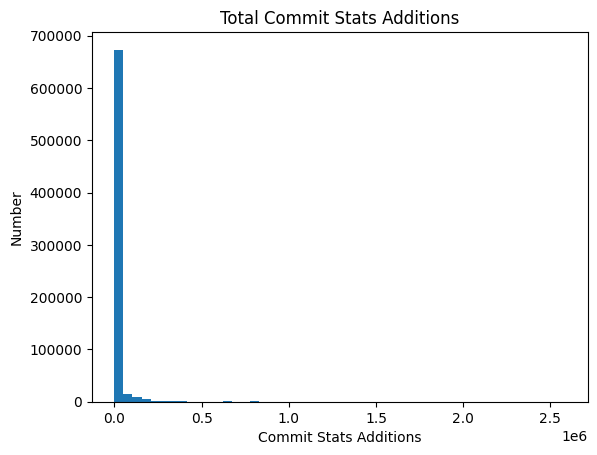

Mean and median of number of additions:  17604.7 769.0
90% quantile:  29451.0
95% quantile:  65971.0
99% quantile:  261039.0


In [6]:
import matplotlib.pyplot as plt

data = df_commit_details[["commit_stats_additions"]]

plt.figure()
plt.hist(data, bins=50)
plt.xlabel("Commit Stats Additions")
plt.ylabel("Number")
plt.title("Total Commit Stats Additions")
plt.show()

print("Mean and median of number of additions: ", round(data.mean().values[0],1), data.median().values[0])
q = data.quantile(0.9).values[0]
print("90% quantile: ", data.quantile(0.9).values[0])
print("95% quantile: ", data.quantile(0.95).values[0])
print("99% quantile: ", data.quantile(0.99).values[0])

# Joins

In [7]:
# Join the issues to pr tables, 
# by first joining the issues table with the related issues table on issue id
# then joining the pr table on the pr id 
renamed_issues = df_issues[["id", "title", "body", "number"]].rename(columns={"id": "issue_id", "title": "issue_title",
                     "body": "issue_body", "number": "issue_number"})
renamed_prs = df_prs[["id", "number", "title", "body", "agent", "repo_id", "repo_url", "html_url"]].rename(columns={"id": "pr_id", "number": "pr_number", "title": "pr_title", "body": "pr_body"})
issue_to_pr = renamed_issues.merge(df_related_issues[["pr_id", "issue_id"]], on="issue_id").merge(renamed_prs, on="pr_id")

display(issue_to_pr.head())

# Join the issues pr tables to commit details 
# using the pr id 
issue_to_commit_details = issue_to_pr.merge(df_commit_details[["pr_id", "sha", "message", "filename", "status", "additions", "deletions", "changes"]], on="pr_id")

display(issue_to_commit_details.head())
print(issue_to_commit_details.shape)
print(issue_to_commit_details.columns)

,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_id,repo_url,html_url
0,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717
1,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3084744894,1553,feat: Add api_key parameter to from_provider f...,# Add api_key parameter to from_provider funct...,Devin,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1553
2,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3084794264,1554,Fix Python 3.9 compatibility issues in from_pr...,# Fix Python 3.9 compatibility issues in from_...,Devin,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1554
3,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...
4,2975033421,Broken links to notebooks in documentation,On [this documentation page](https://incatools...,836,2975165913,837,Fix broken links to notebooks,to fix #836 \r\n\r\nUpdated all links pointing...,Claude_Code,475072415,https://api.github.com/repos/INCATools/ontolog...,https://github.com/INCATools/ontology-access-k...


,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_id,repo_url,html_url,sha,message,filename,status,additions,deletions,changes
0,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,f5dd5e737963ec0f6df35ae8d2fc337aeb0b99fa,feat(auto_client): add comprehensive api_key p...,instructor/auto_client.py,modified,60.0,22.0,82.0
1,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,0e5e9da476f9dac42341238be15461aadac1d460,test(auto_client): add comprehensive tests for...,instructor/auto_client.py,modified,2.0,1.0,3.0
2,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,0e5e9da476f9dac42341238be15461aadac1d460,test(auto_client): add comprehensive tests for...,tests/test_auto_client.py,modified,133.0,0.0,133.0
3,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,64b26da4ae1acd6be60c8957d7d18262eed2534d,docs: add api_key parameter examples to README...,README.md,modified,5.0,0.0,5.0
4,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,653589102,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,64b26da4ae1acd6be60c8957d7d18262eed2534d,docs: add api_key parameter examples to README...,docs/index.md,modified,5.0,0.0,5.0


(13781, 19)
Index(['issue_id', 'issue_title', 'issue_body', 'issue_number', 'pr_id',
       'pr_number', 'pr_title', 'pr_body', 'agent', 'repo_id', 'repo_url',
       'html_url', 'sha', 'message', 'filename', 'status', 'additions',
       'deletions', 'changes'],
      dtype='str')


## Analyze the number of PRs in the remaining dataset

In [8]:
unique_pr_ids = issue_to_commit_details["pr_id"].unique()
len(unique_pr_ids)

559

## Extract commits with the top k% commit stats additions
High additions indicate the issue is likely a feature implementation and not a simple bug fix. 

In [9]:
# Sum the issues to commit details in the additions column, per PR 
issue_to_commit_details_sum_additions = issue_to_commit_details.groupby("pr_id")["additions"].sum() 

# Find the pr_ids corresponding to the top 5% of additions 
K = 10
threshold = issue_to_commit_details_sum_additions.quantile(1-K/100) 

# Find the pr ids whose total number of additions is in the top K% 
significant_pr_ids = issue_to_commit_details_sum_additions[issue_to_commit_details_sum_additions > threshold].index 
issue_to_commit_details_filtered = issue_to_commit_details[issue_to_commit_details["pr_id"].isin(significant_pr_ids)]

# Display the selected pr ids 
display(issue_to_commit_details_filtered)
print(f"Number of PRs in the top {K}%: {len(issue_to_commit_details_filtered["pr_id"].unique())}")

# Display the addition counts for each pull request 
print(issue_to_commit_details_filtered.groupby("pr_id")["additions"].sum().sort_values(ascending=False))

,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_id,repo_url,html_url,sha,message,filename,status,additions,deletions,changes
12,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,debug_certain_confidence.py,added,74.0,0.0,74.0
13,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,server.py,modified,7.0,0.0,7.0
14,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/__init__.py,modified,3.0,0.0,3.0
15,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/conversation_base_test.py,modified,3.0,2.0,5.0
16,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/test_debugworkflow_validation.py,added,552.0,0.0,552.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13605,3172916524,[BUG] crewai create with trailing slash create...,### Description\n\nThis is a minor issue.\n\nW...,3059,3172939109,3060,Fix: Normalize project names by stripping trai...,# Fix: Normalize project names by stripping tr...,Devin,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/3060,6a171190f94b566fa3d0c3f4d60865d033e7dcf9,Merge branch 'main' into devin/1750789857-fix-...,docs/pt-BR/tools/database-data/qdrantvectorsea...,added,272.0,0.0,272.0
13606,3172916524,[BUG] crewai create with trailing slash create...,### Description\n\nThis is a minor issue.\n\nW...,3059,3172939109,3060,Fix: Normalize project names by stripping trai...,# Fix: Normalize project names by stripping tr...,Devin,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/3060,1de749d192b1a2b07b633bd8988e3a43b8baba36,Merge branch 'main' into devin/1750789857-fix-...,pyproject.toml,modified,4.0,1.0,5.0
13607,3172916524,[BUG] crewai create with trailing slash create...,### Description\n\nThis is a minor issue.\n\nW...,3059,3172939109,3060,Fix: Normalize project names by stripping trai...,# Fix: Normalize project names by stripping tr...,Devin,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/3060,1de749d192b1a2b07b633bd8988e3a43b8baba36,Merge branch 'main' into devin/1750789857-

Number of PRs in the top 10%: 56
pr_id
3161009617    65399.0
2982204377    53384.0
2832575560    42324.0
3081388781    33397.0
3219667345    32759.0
3125531606    31426.0
3172939109    30568.0
3071076995    27642.0
3164250713    27110.0
2964974679    24571.0
2840453828    21151.0
3182767311    19974.0
2850852315    19244.0
3222599276    18966.0
3225271859    18877.0
3085398469    18263.0
3182150653    17225.0
2894930869    16494.0
2802453203    15111.0
2885416773    14473.0
3076981888    13838.0
3076722865    13826.0
3139579722    13303.0
3214469484    12341.0
3176132312    11161.0
3151697572    10341.0
3120603357     9875.0
3155084033     9510.0
3195676820     8259.0
3102790603     8095.0
3132740864     6853.0
3135068930     5905.0
3046981078     5579.0
3161317787     5554.0
3056995446     5026.0
3193524394     4798.0
3226556821     4615.0
3089009485     4249.0
3158615630     3644.0
3194998721     3377.0
3074925487     3247.0
3223695360     3214.0
3090570894     3200.0
3203097519     

In [10]:
# Remove duplicates for each pr id and drop the additions, deletions and changes columns, as they are no longer needed 
df_selected = issue_to_commit_details_filtered.drop_duplicates(subset='pr_id', keep='first').drop(columns=["additions", "deletions", "changes"])
display(df_selected)

print(f"Number of pull requests: {len(df_selected)}")
print(f"Number of unique repo ids: {len(df_selected["repo_id"].unique())}")

# print all github repo urls 
print('\n'.join(df_selected["html_url"].tolist()))

,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_id,repo_url,html_url,sha,message,filename,status
12,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,998428732,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,debug_certain_confidence.py,added
293,3244979480,Implement context engineering,Implement below in src/praisonai-agents/praiso...,1018,3245011006,1021,Implement Context Engineering - Add ContextAge...,## Summary\r\n\r\nImplements Context Engineeri...,Claude_Code,774497032,https://api.github.com/repos/MervinPraison/Pra...,https://github.com/MervinPraison/PraisonAI/pul...,c4ab62908365cb9406e950150572951feeaaea21,Implement Context Engineering - Add ContextAge...,examples/python/agents/context-agent.py,added
369,3083309439,Add MCP middleware,### Enhancement Description\n\nIntroduce MCP-s...,549,3158615630,870,Add MCP Middleware,## Summary\n\nThis PR introduces **MCP Middlew...,Claude_Code,896296825,https://api.github.com/repos/jlowin/fastmcp,https://github.com/jlowin/fastmcp/pull/870,0702bad1c2aa9509b89a8c01c985b63db08c64d8,Add single-component methods,src/fastmcp/server/context.py,modified
591,2066403237,[ServiceBus/EventHubs] add samples using threa...,"Currently, in SB, we don't have samples to sho...",33710,3125531606,41463,Add comprehensive thread and coroutine safety ...,This PR addresses [#33710](https://github.com/...,Copilot,4127088,https://api.github.com/repos/Azure/azure-sdk-f...,https://github.com/Azure/azure-sdk-for-python/...,f98c1f7e7194b601b57ac63702a243a841187020,Initial plan for issue,NaN,NaN
1140,3172649219,[Feature] AliESA 阿里云边缘安全加速,> 能否增加更新「阿里云 ESA」的 DNS 记录？\n> \n> https://help...,490,3193524394,498,feat(AliESA) 阿里云边缘安全加速 DNS provider support,This PR implements a new DNS provider for Alib...,Copilot,60844169,https://api.github.com/repos/NewFuture/DDNS,https://github.com/NewFuture/DDNS/pull/498,12171f5fcb081069091ada5b4dc0af51611931b9,Initial plan,NaN,NaN
1329,3225563965,[Feature] 腾讯云 EdgeOne 国内版/国际版,## DNS 服务商信息\n\n- **官网 (Website):** \n\nhttps:...,516,3226556821,521,feat(provider:edgeone): 支持腾讯EdgeOne Add Tencen...,Implements support for Tencent Cloud EdgeOne (...,Copilot,60844169,https://api.github.com/repos/NewFuture/DDNS,https://github.com/NewFuture/DDNS/pull/521,fcb02b6977c01d28abcf8effa415b1a9e75803d2,Initial plan,NaN,NaN
1439,3230528403,[feature]多provider和多配置文件支持,## 描述场景和问题 (Is your feature request related to...,523,3230529031,524,feature(config): Multi-provider and multi-conf...,This PR implements multi-provider and multi-co...,Copilot,60844169,https://api.github.com/repos/NewFuture/DDNS,https://github.com/NewFuture/DDNS/pull/524,053b65bdb6420d61dd0350898fa1f257cc62cc6e,Initial plan,NaN,NaN
1757,3208199766,No support for multi-page .TIF images,### Bug\nI've noticed that the current impleme...,1903,3219667345,1928,fix: multi-page image support (tiff),## Problem\n\nMulti-page TIFF images were only...,Copilot,826168160,https://api.github.com/repos/docling-project/d...,https://github.com/docling-project/docling/pul...,420df478f302ea4aab1762be467dc4a90a7d7903,Initial plan,NaN,NaN
1944,946036627,Ensure storage rule is removed if lets encrypt...,**Description**\r\nThe lets encrypt script add...,472,3176132312,4602,Unify storage account public access management...,### Problem\r\nMultiple scripts across the cod...,Copilot,344511263,https://api.github.com/repos/microsoft/AzureTRE,https://github.com/microsoft/AzureTRE/pull/4602,e586d42982805518179d415f8b4c9c35cc287c24,Initial plan,NaN,NaN
2029,2966940153,Add sort/filter options to Workspace list,## Description\n\nAs a TRE User I want an effi...,4462,3182150653,4608,Add sort/filter options to Workspace list,This PR imple

Number of pull requests: 56
Number of unique repo ids: 26
https://github.com/BeehiveInnovations/zen-mcp-server/pull/95
https://github.com/MervinPraison/PraisonAI/pull/1021
https://github.com/jlowin/fastmcp/pull/870
https://github.com/Azure/azure-sdk-for-python/pull/41463
https://github.com/NewFuture/DDNS/pull/498
https://github.com/NewFuture/DDNS/pull/521
https://github.com/NewFuture/DDNS/pull/524
https://github.com/docling-project/docling/pull/1928
https://github.com/microsoft/AzureTRE/pull/4602
https://github.com/microsoft/AzureTRE/pull/4608
https://github.com/microsoft/AzureTRE/pull/4552
https://github.com/microsoft/AzureTRE/pull/4554
https://github.com/microsoft/AzureTRE/pull/4551
https://github.com/microsoft/AzureTRE/pull/4589
https://github.com/microsoft/AzureTRE/pull/4610
https://github.com/microsoft/Olive/pull/1907
https://github.com/microsoft/autogen/pull/6563
https://github.com/microsoft/autogen/pull/6684
https://github.com/microsoft/autogen/pull/6690
https://github.com/micro

In [ ]:
# Analyze the agent distribution per repo 
df_selected.groupby('agent')['repo_id'].nunique()

agent
Claude_Code      3
Copilot         17
Cursor           2
Devin            3
OpenAI_Codex     1
Name: repo_id, dtype: int64

## Git clone the repo before and after each pull request

In [13]:
from dotenv import load_dotenv
import os

load_dotenv()

USERNAME = os.environ["GITHUB_USERNAME"]
TOKEN = os.environ["GITHUB_TOKEN"]

In [14]:
# Given a row in the issue_to_commit_details, clone its before and after version to the folder 
# Will not clone or modify any files if it already exists. 
# /pr_id/before and /pr_id/after
import os 
import subprocess
import requests 
def clone_repo(row): 
    # Append the pr number to the repo url 
    # https://docs.github.com/en/rest/pulls/pulls?apiVersion=2026-03-10
    fetchUrl = f"{row["repo_url"]}/pulls/{row["pr_number"]}"
    pr_id = row["pr_id"]
    
    # GET request to the GitHub API 
    headers = {"Authorization": f"Bearer {TOKEN}",}
    response = requests.get(fetchUrl, headers=headers)
    if response.status_code != 200: 
        raise Exception(f"{response.status_code} Fail to fetch url {fetchUrl}")

    # Extract the base SHA (before) and merge commit SHA (after) 
    resjson = response.json()
    base_SHA = resjson["base"]["sha"]
    merge_commit_SHA = resjson["merge_commit_sha"]

    # Obtain the base clone url and name
    # Base branch is the branch where changes are pulled into 
    base_clone_url = resjson["base"]["repo"]["clone_url"]
    base_repo_name = resjson["base"]["repo"]["name"]

    # Create a before and after folder for each pr id 
    before_dir = f"snapshots/{pr_id}/before"
    after_dir = f"snapshots/{pr_id}/after"
    os.makedirs(before_dir, exist_ok=True)
    os.makedirs(after_dir, exist_ok=True)

    # clone the before and after version of the repo, checking out to the base and commit SHA
    # Only perform this when the folders are empty 
    wd = os.getcwd()  # for changing back to the current working dir later 
    if len(os.listdir(before_dir)) == 0:  
        os.chdir(before_dir)
        subprocess.run(["git", "clone", base_clone_url])
        os.chdir(base_repo_name)
        subprocess.run(["git", "checkout", base_SHA])  # SHA before merge 
        os.chdir(wd)  

    if len(os.listdir(after_dir)) == 0:  
        os.chdir(after_dir)
        subprocess.run(["git", "clone", base_clone_url])
        os.chdir(base_repo_name)
        subprocess.run(["git", "checkout", merge_commit_SHA])  # SHA after merge 
        os.chdir(wd)  


In [15]:
i = 0
first_row = df_selected.iloc[i] 
first_row

issue_id                                               3164229012
issue_title              Workflows Coming Soon - tools reimagined
issue_body      ### Project Version\n\n5.5.0\n\n### Bug Descri...
issue_number                                                   94
pr_id                                                  3164250713
pr_number                                                      95
pr_title        🚀 Major Enhancement: Workflow-Based Tool Archi...
pr_body         # 🚀 Major Enhancement: Workflow-Based Tool Arc...
agent                                                 Claude_Code
repo_id                                                 998428732
repo_url        https://api.github.com/repos/BeehiveInnovation...
html_url        https://github.com/BeehiveInnovations/zen-mcp-...
sha                      316db13a3a3bf01572e588e17bfc8dd4780c8a35
message                            WIP: new workflow architecture
filename                              debug_certain_confidence.py
status    

In [16]:

clone_repo(first_row)